In [17]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Association rules and ML
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cosine

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [18]:
# Load data
df = pd.read_excel('cleaned_data.xlsx')

# Convert date column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Select and rename relevant columns
df = df[['Client number', 'Product Name', 'Product Type', 'Transaction Date', 
         'Transaction Amount (SGD)', 'Fund House/Issuer/Exchange', 
         'Product Category/DPMS Risk Level/Company Portfolio Risk Level']].copy()

df.columns = ['Client', 'Product', 'ProductType', 'Date', 'Amount', 'Issuer', 'Category']

# Sort by Client and Date
df = df.sort_values(['Client', 'Date']).reset_index(drop=True)

print(f"✅ Data loaded: {len(df)} transactions")
print(f"   Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"   Unique clients: {df['Client'].nunique()}")
print(f"   Unique product types: {df['ProductType'].nunique()}")
print(f"\n📊 Product Type Distribution:")
print(df['ProductType'].value_counts())

✅ Data loaded: 3171 transactions
   Date range: 2021-09-01 00:00:00 to 2025-09-26 00:00:00
   Unique clients: 190
   Unique product types: 5

📊 Product Type Distribution:
ProductType
STOCK    1805
ETF       463
UT        431
DPMS      264
BOND      208
Name: count, dtype: int64


DATASET OVERVIEW

📏 Shape: 3171 transactions × 7 columns

📅 Date Range: 2021-09-01 to 2025-09-26
   Duration: 1486 days

👥 Unique Clients: 190
📦 Unique Product Types: 5

💰 Transaction Amount Statistics (SGD):
count    3.171000e+03
mean     1.933195e+04
std      5.212408e+04
min      7.703000e+01
25%      2.655490e+03
50%      6.250000e+03
75%      1.859401e+04
max      1.000582e+06
Name: Amount, dtype: float64


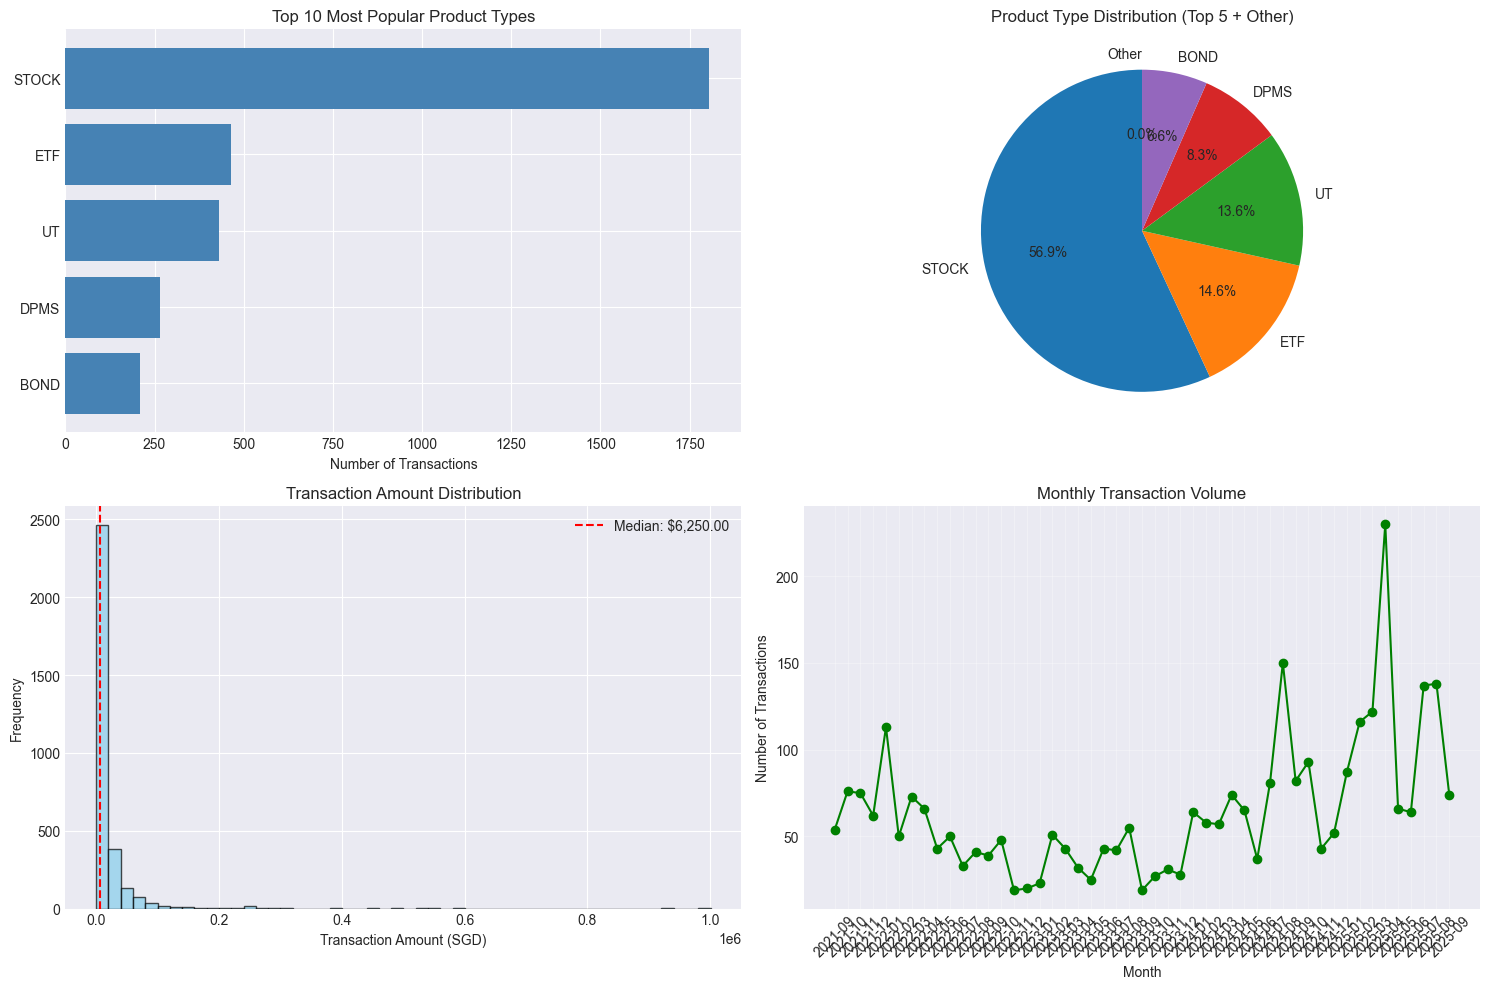


✅ EDA complete!


In [19]:
# Display basic statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\n📏 Shape: {df.shape[0]} transactions × {df.shape[1]} columns")
print(f"\n📅 Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   Duration: {(df['Date'].max() - df['Date'].min()).days} days")
print(f"\n👥 Unique Clients: {df['Client'].nunique()}")
print(f"📦 Unique Product Types: {df['ProductType'].nunique()}")
print(f"\n💰 Transaction Amount Statistics (SGD):")
print(df['Amount'].describe())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 10 Product Types
product_type_counts = df['ProductType'].value_counts().head(10)
axes[0, 0].barh(product_type_counts.index, product_type_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_title('Top 10 Most Popular Product Types')
axes[0, 0].invert_yaxis()

# Product Type Distribution (Pie)
top_5_types = df['ProductType'].value_counts().head(5)
other_count = df['ProductType'].value_counts()[5:].sum()
pie_data = pd.concat([top_5_types, pd.Series({'Other': other_count})])
axes[0, 1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Product Type Distribution (Top 5 + Other)')

# Transaction Amount Distribution
axes[1, 0].hist(df['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['Amount'].median(), color='red', linestyle='--', 
                    label=f'Median: ${df["Amount"].median():,.2f}')
axes[1, 0].set_xlabel('Transaction Amount (SGD)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Transaction Amount Distribution')
axes[1, 0].legend()

# Monthly Transaction Volume
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_txns = df.groupby('YearMonth').size()
axes[1, 1].plot(monthly_txns.index.astype(str), monthly_txns.values, marker='o', color='green')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].set_title('Monthly Transaction Volume')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ EDA complete!")

In [20]:
# Calculate client-level features
print("🔧 Engineering client-level features...")

client_features = df.groupby('Client').agg({
    'Amount': ['mean', 'median', 'std', 'sum', 'count'],
    'Date': ['min', 'max'],
    'ProductType': lambda x: x.value_counts().index[0] if len(x) > 0 else None  # Most frequent
}).reset_index()

client_features.columns = ['Client', 'Avg_Amount', 'Median_Amount', 'Std_Amount', 
                           'Total_Invested', 'Num_Transactions', 'First_Transaction', 
                           'Last_Transaction', 'Favorite_ProductType']

# Calculate derived features
client_features['Days_Active'] = (client_features['Last_Transaction'] - 
                                  client_features['First_Transaction']).dt.days

# Calculate unique product types per client
unique_types = df.groupby('Client')['ProductType'].nunique().reset_index()
unique_types.columns = ['Client', 'Unique_ProductTypes']
client_features = client_features.merge(unique_types, on='Client')

# Calculate average days between purchases
df_sorted = df.sort_values(['Client', 'Date'])
df_sorted['Days_Since_Last'] = df_sorted.groupby('Client')['Date'].diff().dt.days

avg_days_between = df_sorted.groupby('Client')['Days_Since_Last'].agg(['mean', 'median']).reset_index()
avg_days_between.columns = ['Client', 'Avg_Days_Between_Purchases', 'Median_Days_Between_Purchases']
client_features = client_features.merge(avg_days_between, on='Client')

# Fill NaN values for clients with single transaction
client_features['Avg_Days_Between_Purchases'].fillna(30, inplace=True)
client_features['Median_Days_Between_Purchases'].fillna(30, inplace=True)

print(f"✅ Client features created: {len(client_features)} clients")
print("\n📊 Sample of client features:")
client_features.head()

🔧 Engineering client-level features...
✅ Client features created: 190 clients

📊 Sample of client features:


,Client,Avg_Amount,Median_Amount,Std_Amount,Total_Invested,Num_Transactions,First_Transaction,Last_Transaction,Favorite_ProductType,Days_Active,Unique_ProductTypes,Avg_Days_Between_Purchases,Median_Days_Between_Purchases
0,B1,1827.76375,1241.015,1847.713183,14622.11,8,2021-10-29,2022-09-01,DPMS,307,3,43.857143,7.0
1,B10,44893.01670,25514.280,49273.928380,4489301.67,100,2021-09-07,2025-09-25,STOCK,1479,3,14.939394,6.0
2,B100,674.08600,593.190,310.930473,3370.43,5,2022-04-05,2022-08-18,ETF,135,2,33.750000,22.0
3,B101,10074.42000,10074.420,NaN,10074.42,1,2022-04-08,2022-04-08,ETF,0,1,30.000000,30.0
4,B102,35301.87000,30601.910,22719.428171,105905.61,3,2022-04-12,2024-04-01,DPMS,720,1,360.000000,360.0


In [21]:
# Calculate product type level features
print("🔧 Engineering product type features...")

product_type_features = df.groupby('ProductType').agg({
    'Amount': ['mean', 'median', 'count'],
    'Client': lambda x: x.nunique()
}).reset_index()

product_type_features.columns = ['ProductType', 'Avg_ProductType_Amount', 
                                  'Median_ProductType_Amount', 'ProductType_Popularity', 
                                  'Unique_Buyers']

print(f"✅ Product type features created: {len(product_type_features)} product types")
print("\n📊 Product type features:")
print(product_type_features.sort_values('ProductType_Popularity', ascending=False).head(10))

🔧 Engineering product type features...
✅ Product type features created: 5 product types

📊 Product type features:
  ProductType  Avg_ProductType_Amount  Median_ProductType_Amount  \
3       STOCK            13826.627684                    5031.08   
2         ETF            18640.735356                    4834.77   
4          UT            23446.861836                    5000.00   
1        DPMS            24952.225038                   15300.00   
0        BOND            52985.092500                   20423.60   

   ProductType_Popularity  Unique_Buyers  
3                    1805             91  
2                     463             75  
4                     431             65  
1                     264             89  
0                     208             35  


🎯 Performing Customer Clustering...


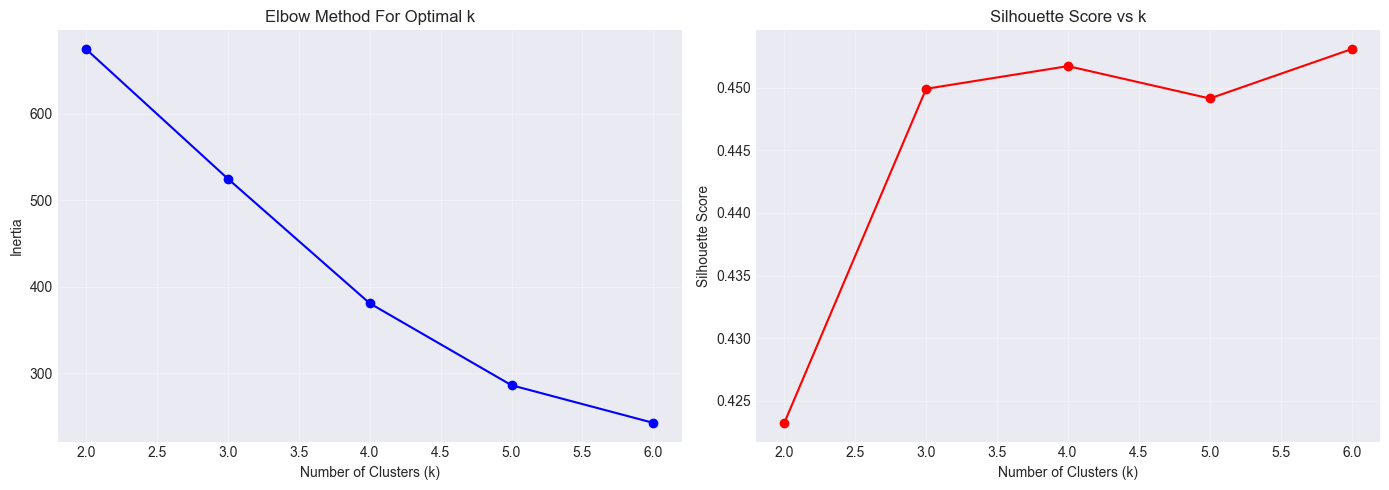


✅ Customers segmented into 4 clusters

📊 Cluster Distribution:
Cluster
0     48
1    118
2     23
3      1
Name: count, dtype: int64

🔍 Cluster Characteristics:
         Avg_Amount  Num_Transactions  Total_Invested  Unique_ProductTypes  \
Cluster                                                                      
0          17773.53             12.21       204108.27                 1.96   
1          27465.32              6.32       167311.96                 1.50   
2          17523.12             79.83      1273917.54                 3.57   
3         820498.67              3.00      2461496.00                 2.00   

         Avg_Days_Between_Purchases  
Cluster                              
0                            226.21  
1                             30.22  
2                             21.22  
3                            485.00  

🏷️ Cluster Names:
   Cluster 0: High-Value Conservative (48 customers)
      Avg Amount: $17,773.53 | Avg Frequency: 226 days
   Cluster 1: 

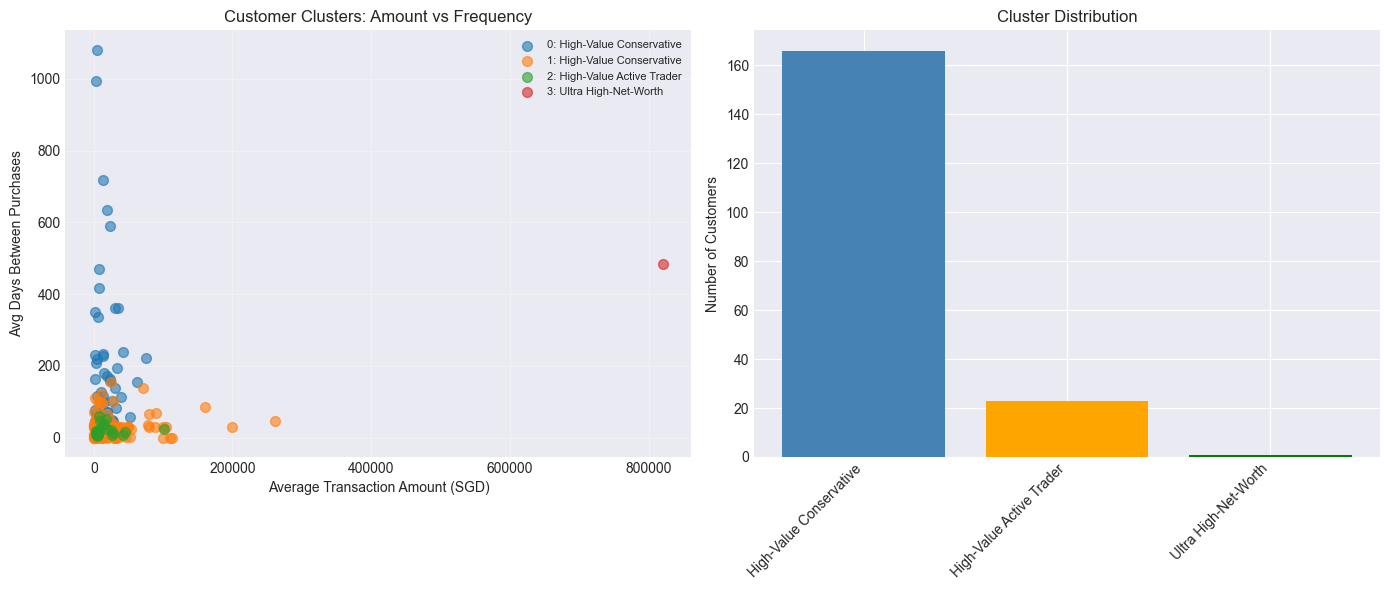


✅ Clustering complete!

📝 Note: Customers with only 1 transaction get default frequency of 30 days (handled in Cell 4)


In [22]:
# ========================================
# CUSTOMER CLUSTERING
# ========================================
print("🎯 Performing Customer Clustering...")

# Prepare features for clustering
clustering_features = client_features[['Avg_Amount', 'Num_Transactions', 
                                       'Unique_ProductTypes', 'Days_Active',
                                       'Avg_Days_Between_Purchases']].copy()

# Handle any remaining NaN values
clustering_features = clustering_features.fillna(clustering_features.median())

# Standardize features
scaler = StandardScaler()
clustering_features_scaled = scaler.fit_transform(clustering_features)

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 7)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustering_features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(clustering_features_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Perform clustering with optimal k (using 4 clusters)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
client_features['Cluster'] = kmeans_final.fit_predict(clustering_features_scaled)

# Analyze clusters
print(f"\n✅ Customers segmented into {optimal_k} clusters\n")
print("📊 Cluster Distribution:")
print(client_features['Cluster'].value_counts().sort_index())

print("\n🔍 Cluster Characteristics:")
cluster_summary = client_features.groupby('Cluster').agg({
    'Avg_Amount': 'mean',
    'Num_Transactions': 'mean',
    'Total_Invested': 'mean',
    'Unique_ProductTypes': 'mean',
    'Avg_Days_Between_Purchases': 'mean'
}).round(2)

print(cluster_summary)

# FIXED: Assign cluster names with better logic
cluster_names = {}
overall_median_amount = client_features['Avg_Amount'].median()
overall_median_freq = client_features['Avg_Days_Between_Purchases'].median()

for cluster_id in range(optimal_k):
    cluster_data = client_features[client_features['Cluster'] == cluster_id]
    avg_amount = cluster_data['Avg_Amount'].mean()
    avg_frequency = cluster_data['Avg_Days_Between_Purchases'].mean()
    avg_transactions = cluster_data['Num_Transactions'].mean()
    
    # More granular naming logic
    if avg_amount > 100000:  # Ultra high value
        cluster_names[cluster_id] = "Ultra High-Net-Worth"
    elif avg_amount > overall_median_amount and avg_frequency < 30:
        cluster_names[cluster_id] = "High-Value Active Trader"
    elif avg_amount > overall_median_amount and avg_frequency >= 30:
        cluster_names[cluster_id] = "High-Value Conservative"
    elif avg_frequency < 30 and avg_transactions > 10:
        cluster_names[cluster_id] = "Active Retail Trader"
    elif avg_frequency < 50:
        cluster_names[cluster_id] = "Moderate Investor"
    else:
        cluster_names[cluster_id] = "Passive Long-Term Investor"

client_features['Cluster_Name'] = client_features['Cluster'].map(cluster_names)

print("\n🏷️ Cluster Names:")
for cluster_id, name in cluster_names.items():
    count = len(client_features[client_features['Cluster'] == cluster_id])
    avg_amt = client_features[client_features['Cluster'] == cluster_id]['Avg_Amount'].mean()
    avg_freq = client_features[client_features['Cluster'] == cluster_id]['Avg_Days_Between_Purchases'].mean()
    print(f"   Cluster {cluster_id}: {name} ({count} customers)")
    print(f"      Avg Amount: ${avg_amt:,.2f} | Avg Frequency: {avg_freq:.0f} days")

# Visualize clusters
fig = plt.figure(figsize=(14, 6))

# 2D visualization (Amount vs Frequency)
ax1 = fig.add_subplot(121)
for cluster_id in range(optimal_k):
    cluster_data = client_features[client_features['Cluster'] == cluster_id]
    ax1.scatter(cluster_data['Avg_Amount'], cluster_data['Avg_Days_Between_Purchases'],
               label=f"{cluster_id}: {cluster_names[cluster_id]}", alpha=0.6, s=50)
ax1.set_xlabel('Average Transaction Amount (SGD)')
ax1.set_ylabel('Avg Days Between Purchases')
ax1.set_title('Customer Clusters: Amount vs Frequency')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Cluster size
ax2 = fig.add_subplot(122)
cluster_counts = client_features['Cluster_Name'].value_counts()
ax2.bar(range(len(cluster_counts)), cluster_counts.values, color=['steelblue', 'orange', 'green', 'red'][:len(cluster_counts)])
ax2.set_xticks(range(len(cluster_counts)))
ax2.set_xticklabels(cluster_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Number of Customers')
ax2.set_title('Cluster Distribution')

plt.tight_layout()
plt.show()

print("\n✅ Clustering complete!")
print(f"\n📝 Note: Customers with only 1 transaction get default frequency of 30 days (handled in Cell 4)")

In [23]:
# Merge all features into enhanced dataframe
print("🔧 Creating enhanced dataset...")

df_enhanced = df.merge(client_features[['Client', 'Avg_Amount', 'Median_Amount', 
                                         'Num_Transactions', 'Unique_ProductTypes', 
                                         'Favorite_ProductType', 'Days_Active',
                                         'Avg_Days_Between_Purchases', 'Cluster', 
                                         'Cluster_Name']], 
                       on='Client', how='left')

df_enhanced = df_enhanced.merge(product_type_features, on='ProductType', how='left')

# Add temporal features
df_enhanced['DayOfWeek'] = df_enhanced['Date'].dt.dayofweek
df_enhanced['Month'] = df_enhanced['Date'].dt.month
df_enhanced['Quarter'] = df_enhanced['Date'].dt.quarter

print(f"✅ Enhanced dataset created: {df_enhanced.shape}")
print("\n📊 Sample of enhanced data:")
df_enhanced.head()

🔧 Creating enhanced dataset...
✅ Enhanced dataset created: (3171, 24)

📊 Sample of enhanced data:


,Client,Product,ProductType,Date,Amount,Issuer,Category,YearMonth,Avg_Amount,Median_Amount,Num_Transactions,Unique_ProductTypes,Favorite_ProductType,Days_Active,Avg_Days_Between_Purchases,Cluster,Cluster_Name,Avg_ProductType_Amount,Median_ProductType_Amount,ProductType_Popularity,Unique_Buyers,DayOfWeek,Month,Quarter
0,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2021-10-29,3500.00,-,Aggressive,2021-10,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,High-Value Conservative,24952.225038,15300.00,264,89,4,10,4
1,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-02-28,2000.00,-,Aggressive,2022-02,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,High-Value Conservative,24952.225038,15300.00,264,89,0,2,1
2,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-06-02,5000.00,-,Aggressive,2022-06,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,High-Value Conservative,24952.225038,15300.00,264,89,3,6,2
3,B1,DigiCore Reit USD,STOCK,2022-08-18,249.85,SGX,Equity,2022-08,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,High-Value Conservative,13826.627684,5031.08,1805,91,3,8,3
4,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-08-18,3000.00,-,Aggressive,2022-08,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,High-Value Conservative,24952.225038,15300.00,264,89,3,8,3


In [24]:
# Analyze product transitions (using actual product names)
print("🔀 Analyzing product transitions...")

transitions = []

for client in df['Client'].unique():
    client_data = df[df['Client'] == client].sort_values('Date')
    
    for i in range(len(client_data) - 1):
        from_product = client_data.iloc[i]['Product']
        to_product = client_data.iloc[i + 1]['Product']
        from_type = client_data.iloc[i]['ProductType']
        to_type = client_data.iloc[i + 1]['ProductType']
        
        # Track all product-to-product transitions (including same type)
        if from_product != to_product:
            transitions.append({
                'Client': client,
                'From_Product': from_product,
                'To_Product': to_product,
                'From_ProductType': from_type,
                'To_ProductType': to_type
            })

transitions_df = pd.DataFrame(transitions)

print(f"✅ Identified {len(transitions_df)} product transitions")

# Calculate transition probabilities BY PRODUCT TYPE
if len(transitions_df) > 0:
    # Group by product type transitions
    transition_counts = transitions_df.groupby(['From_ProductType', 'To_ProductType']).size().reset_index(name='Count')
    total_from = transitions_df.groupby('From_ProductType').size().reset_index(name='Total')
    
    transition_probs = transition_counts.merge(total_from, on='From_ProductType')
    transition_probs['Probability'] = transition_probs['Count'] / transition_probs['Total']
    transition_probs = transition_probs.sort_values('Probability', ascending=False)
    
    print("\n📊 Top 15 Product Type Transitions:")
    print(transition_probs[['From_ProductType', 'To_ProductType', 'Count', 'Probability']].head(15))
    
    # Also show sample of actual product transitions
    print("\n📦 Sample Product-Level Transitions:")
    sample_transitions = transitions_df[['From_Product', 'To_Product', 'From_ProductType', 'To_ProductType']].head(10)
    print(sample_transitions)
else:
    transition_probs = pd.DataFrame(columns=['From_ProductType', 'To_ProductType', 'Count', 'Probability'])
    print("⚠️ No transitions found")

🔀 Analyzing product transitions...
✅ Identified 2281 product transitions

📊 Top 15 Product Type Transitions:
   From_ProductType To_ProductType  Count  Probability
18            STOCK          STOCK   1090     0.831426
0              BOND           BOND    145     0.771277
24               UT             UT    203     0.738182
12              ETF            ETF    149     0.425714
13              ETF          STOCK    144     0.411429
6              DPMS           DPMS     51     0.324841
8              DPMS          STOCK     38     0.242038
7              DPMS            ETF     35     0.222930
9              DPMS             UT     25     0.159236
3              BOND          STOCK     21     0.111702
17            STOCK            ETF    141     0.107551
23               UT          STOCK     27     0.098182
21               UT           DPMS     25     0.090909
11              ETF           DPMS     31     0.088571
1              BOND           DPMS     12     0.063830

📦 Sample P

🛒 Performing market basket analysis...
✅ Found 31 frequent product type combinations
✅ Generated 115 association rules


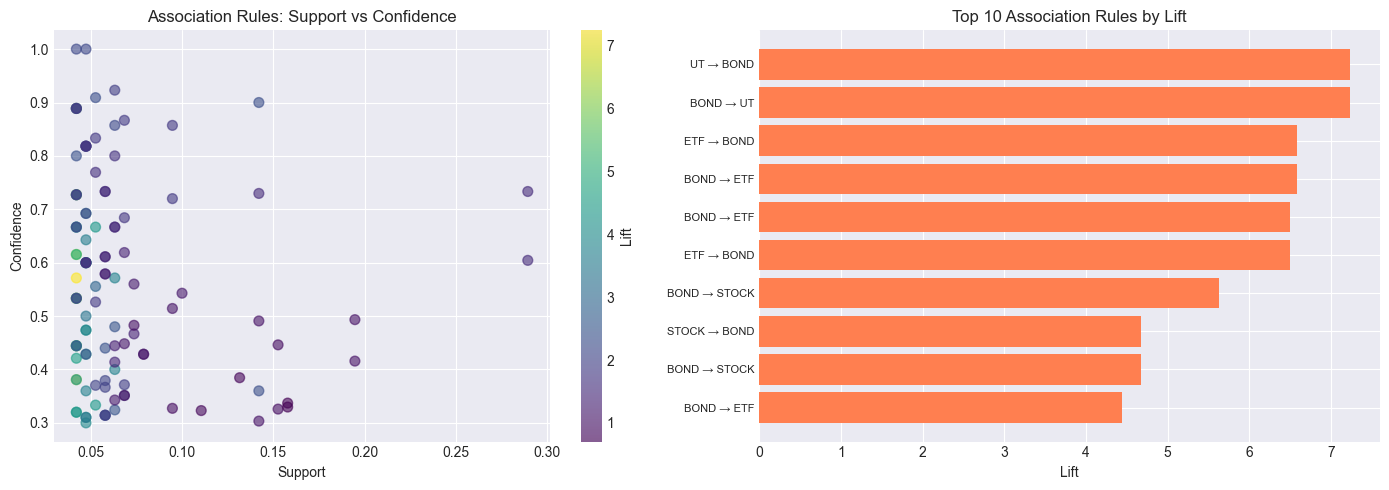


📊 Top 10 Association Rules:
   ['UT', 'STOCK', 'DPMS'] → ['BOND', 'ETF']
   Support: 0.042 | Confidence: 0.571 | Lift: 7.238

   ['BOND', 'ETF'] → ['UT', 'STOCK', 'DPMS']
   Support: 0.042 | Confidence: 0.533 | Lift: 7.238

   ['ETF', 'UT'] → ['BOND', 'STOCK', 'DPMS']
   Support: 0.042 | Confidence: 0.381 | Lift: 6.580

   ['BOND', 'STOCK', 'DPMS'] → ['ETF', 'UT']
   Support: 0.042 | Confidence: 0.727 | Lift: 6.580

   ['BOND', 'STOCK'] → ['ETF', 'UT', 'DPMS']
   Support: 0.042 | Confidence: 0.444 | Lift: 6.496

   ['ETF', 'UT', 'DPMS'] → ['BOND', 'STOCK']
   Support: 0.042 | Confidence: 0.615 | Lift: 6.496

   ['BOND', 'UT', 'ETF'] → ['STOCK', 'DPMS']
   Support: 0.042 | Confidence: 0.889 | Lift: 5.630

   ['STOCK', 'UT'] → ['BOND', 'DPMS', 'ETF']
   Support: 0.042 | Confidence: 0.320 | Lift: 4.677

   ['BOND', 'DPMS', 'ETF'] → ['STOCK', 'UT']
   Support: 0.042 | Confidence: 0.615 | Lift: 4.677

   ['BOND', 'DPMS'] → ['ETF', 'STOCK', 'UT']
   Support: 0.042 | Confidence: 0.421 | Lift

In [25]:
# Market basket analysis using product types
print("🛒 Performing market basket analysis...")

# Create baskets (list of product types per client)
baskets = df.groupby('Client')['ProductType'].apply(list).values.tolist()

# Encode transactions
te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

# Apply Apriori algorithm
frequent_itemsets = apriori(basket_df, min_support=0.02, use_colnames=True)

if len(frequent_itemsets) > 0:
    print(f"✅ Found {len(frequent_itemsets)} frequent product type combinations")
    
    # Generate association rules
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    rules = rules.sort_values('lift', ascending=False)
    
    print(f"✅ Generated {len(rules)} association rules")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Support vs Confidence
    scatter = axes[0].scatter(rules['support'], rules['confidence'], 
                             c=rules['lift'], cmap='viridis', alpha=0.6, s=50)
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Confidence')
    axes[0].set_title('Association Rules: Support vs Confidence')
    plt.colorbar(scatter, ax=axes[0], label='Lift')
    
    # Top rules by lift
    top_rules = rules.head(10)
    axes[1].barh(range(len(top_rules)), top_rules['lift'].values, color='coral')
    axes[1].set_yticks(range(len(top_rules)))
    axes[1].set_yticklabels([f"{list(r['antecedents'])[0]} → {list(r['consequents'])[0]}" 
                             for _, r in top_rules.iterrows()], fontsize=8)
    axes[1].set_xlabel('Lift')
    axes[1].set_title('Top 10 Association Rules by Lift')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 10 Association Rules:")
    for idx, row in rules.head(10).iterrows():
        print(f"   {list(row['antecedents'])} → {list(row['consequents'])}")
        print(f"   Support: {row['support']:.3f} | Confidence: {row['confidence']:.3f} | Lift: {row['lift']:.3f}\n")
else:
    rules = pd.DataFrame()
    print("⚠️ No frequent itemsets found with min_support=0.02")

🤖 Training transaction amount prediction model...

📊 Model Performance:
   MAE:  $11,754.40
   RMSE: $44,121.79
   R²:   0.4114
   MAPE: 182.10%


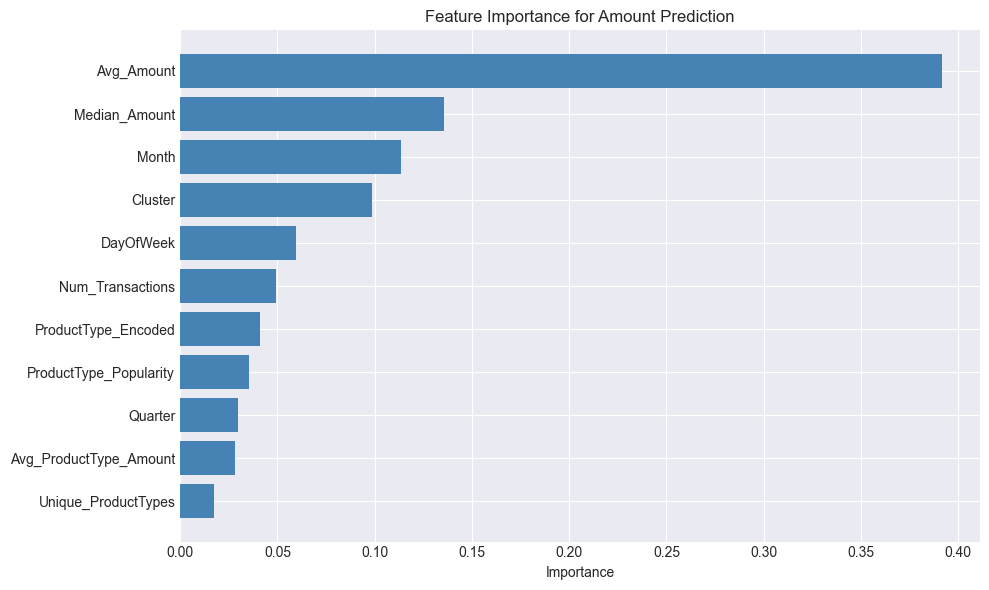


✅ Amount prediction model trained!


In [26]:
# Build model to predict transaction amounts
print("🤖 Training transaction amount prediction model...")

# Prepare features
le = LabelEncoder()
df_enhanced['ProductType_Encoded'] = le.fit_transform(df_enhanced['ProductType'])

amount_features = df_enhanced[['Avg_Amount', 'Median_Amount', 'Num_Transactions',
                               'Unique_ProductTypes', 'Avg_ProductType_Amount',
                               'ProductType_Popularity', 'DayOfWeek', 'Month', 
                               'Quarter', 'ProductType_Encoded', 'Cluster']].copy()

amount_features = amount_features.fillna(amount_features.median())

X = amount_features
y = df_enhanced['Amount']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_amount = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_amount.fit(X_train, y_train)

# Predictions
y_pred = rf_amount.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n📊 Model Performance:")
print(f"   MAE:  ${mae:,.2f}")
print(f"   RMSE: ${rmse:,.2f}")
print(f"   R²:   {r2:.4f}")
print(f"   MAPE: {mape:.2f}%")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': amount_features.columns,
    'Importance': rf_amount.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance for Amount Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✅ Amount prediction model trained!")

In [27]:
# Predict next purchase timing
print("⏰ Predicting next purchase timing...")

df_sorted = df.sort_values(['Client', 'Date'])
df_sorted['Days_Since_Last'] = df_sorted.groupby('Client')['Date'].diff().dt.days

next_purchase_predictions = []

for client in client_features['Client'].unique():
    client_data = df_sorted[df_sorted['Client'] == client]
    
    if len(client_data) >= 1:
        last_transaction_date = client_data['Date'].max()
        
        if len(client_data) >= 2:
            avg_interval = client_data['Days_Since_Last'].dropna().mean()
            median_interval = client_data['Days_Since_Last'].dropna().median()
        else:
            avg_interval = 30
            median_interval = 30
        
        predicted_next_date = last_transaction_date + timedelta(days=median_interval)
        
        next_purchase_predictions.append({
            'Client': client,
            'Last_Transaction_Date': last_transaction_date,
            'Avg_Days_Between': avg_interval,
            'Median_Days_Between': median_interval,
            'Predicted_Next_Purchase_Date': predicted_next_date
        })

timing_predictions = pd.DataFrame(next_purchase_predictions)

print(f"✅ Timing predictions generated for {len(timing_predictions)} clients")
print("\n📊 Sample predictions:")
timing_predictions.head(10)

⏰ Predicting next purchase timing...
✅ Timing predictions generated for 190 clients

📊 Sample predictions:


,Client,Last_Transaction_Date,Avg_Days_Between,Median_Days_Between,Predicted_Next_Purchase_Date
0,B1,2022-09-01,43.857143,7.0,2022-09-08
1,B10,2025-09-25,14.939394,6.0,2025-10-01
2,B100,2022-08-18,33.750000,22.0,2022-09-09
3,B101,2022-04-08,30.000000,30.0,2022-05-08
4,B102,2024-04-01,360.000000,360.0,2025-03-27
5,B103,2025-04-01,361.666667,365.0,2026-04-01
6,B104,2022-06-23,65.000000,65.0,2022-08-27
7,B105,2025-04-10,1081.000000,1081.0,2028-03-26
8,B106,2022-05-06,30.000000,30.0,2022-06-05
9,B107,2022-05-12,30.000000,30.0,2022-06-11


In [28]:
# ========================================
# FIND SIMILAR CUSTOMERS
# ========================================
print("👥 Building similar customers functionality...")

def find_similar_customers(target_client, top_n=10):
    """
    Find customers similar to the target customer based on:
    1. Same cluster
    2. Similar spending patterns
    3. Similar product type preferences
    """
    
    # Get target customer info
    target_info = client_features[client_features['Client'] == target_client].iloc[0]
    target_cluster = target_info['Cluster']
    
    # Get customers from same cluster (excluding target)
    same_cluster = client_features[
        (client_features['Cluster'] == target_cluster) & 
        (client_features['Client'] != target_client)
    ].copy()
    
    if len(same_cluster) == 0:
        print(f"⚠️ No other customers in cluster {target_cluster}")
        return pd.DataFrame()
    
    # Calculate similarity scores
    similarity_scores = []
    
    # Get target's product type preferences
    target_products = set(df[df['Client'] == target_client]['ProductType'].unique())
    
    for _, customer in same_cluster.iterrows():
        customer_id = customer['Client']
        customer_products = set(df[df['Client'] == customer_id]['ProductType'].unique())
        
        # Jaccard similarity for product types
        jaccard_sim = len(target_products & customer_products) / len(target_products | customer_products)
        
        # Spending similarity (inverse of normalized difference)
        spending_diff = abs(target_info['Avg_Amount'] - customer['Avg_Amount'])
        max_spending = max(target_info['Avg_Amount'], customer['Avg_Amount'])
        spending_sim = 1 - (spending_diff / max_spending) if max_spending > 0 else 1
        
        # Frequency similarity
        freq_diff = abs(target_info['Avg_Days_Between_Purchases'] - customer['Avg_Days_Between_Purchases'])
        max_freq = max(target_info['Avg_Days_Between_Purchases'], customer['Avg_Days_Between_Purchases'])
        freq_sim = 1 - (freq_diff / max_freq) if max_freq > 0 else 1
        
        # Combined similarity (weighted average)
        combined_similarity = (0.5 * jaccard_sim + 0.3 * spending_sim + 0.2 * freq_sim)
        
        similarity_scores.append({
            'Client': customer_id,
            'Similarity_Score': combined_similarity,
            'Jaccard_Similarity': jaccard_sim,
            'Spending_Similarity': spending_sim,
            'Frequency_Similarity': freq_sim,
            'Avg_Amount': customer['Avg_Amount'],
            'Num_Transactions': customer['Num_Transactions']
        })
    
    # Sort by similarity
    similar_customers_df = pd.DataFrame(similarity_scores).sort_values(
        'Similarity_Score', ascending=False
    ).head(top_n)
    
    return similar_customers_df

# Test the function
test_client = client_features['Client'].iloc[0]
similar_customers = find_similar_customers(test_client, top_n=10)

print(f"\n✅ Similar customers function created!")
print(f"\n📊 Top 10 customers similar to {test_client}:")
print(similar_customers)

👥 Building similar customers functionality...

✅ Similar customers function created!

📊 Top 10 customers similar to B1:
    Client  Similarity_Score  Jaccard_Similarity  Spending_Similarity  \
49    B177          0.704635            0.666667             0.812047   
85     B25          0.664224            1.000000             0.095859   
12    B119          0.656380            1.000000             0.184566   
113    B94          0.618183            1.000000             0.059523   
112    B93          0.613062            1.000000             0.042455   
0     B100          0.597883            0.666667             0.368804   
83     B22          0.577639            0.333333             0.913882   
95     B61          0.551727            0.666667             0.176316   
105    B80          0.547573            0.666667             0.174503   
30     B15          0.531879            0.666667             0.426000   

     Frequency_Similarity    Avg_Amount  Num_Transactions  
49              

In [29]:
# Enhanced Recommendation Engine
print("🎯 Building enhanced recommendation engine...")

def get_recommendations_for_client(client_id):
    """Generate recommendations using multiple signals"""
    
    client_info = client_features[client_features['Client'] == client_id].iloc[0]
    last_product_type = df[df['Client'] == client_id].sort_values('Date').iloc[-1]['ProductType']
    
    # Signal 1: Sequential patterns
    sequential_rec = None
    seq_conf = 0
    next_candidates = transition_probs[transition_probs['From_ProductType'] == last_product_type]
    if not next_candidates.empty:
        sequential_rec = next_candidates.iloc[0]['To_ProductType']
        seq_conf = next_candidates.iloc[0]['Probability']
    
    # Signal 2: Similar customers
    similar_customers = find_similar_customers(client_id, top_n=10)
    similar_rec = None
    sim_conf = 0
    
    if len(similar_customers) > 0:
        similar_client_ids = similar_customers['Client'].tolist()
        similar_products = df[df['Client'].isin(similar_client_ids)]['ProductType'].value_counts()
        client_products = set(df[df['Client'] == client_id]['ProductType'])
        
        for prod_type in similar_products.index:
            if prod_type not in client_products:
                similar_rec = prod_type
                buyers = df[df['Client'].isin(similar_client_ids) & 
                          (df['ProductType'] == prod_type)]['Client'].nunique()
                sim_conf = buyers / len(similar_customers)
                break
    
    # Combine with weighted voting
    recommendations = {}
    if sequential_rec:
        recommendations[sequential_rec] = recommendations.get(sequential_rec, 0) + (0.4 * seq_conf)
    if similar_rec:
        recommendations[similar_rec] = recommendations.get(similar_rec, 0) + (0.6 * sim_conf)
    
    # Fallback: Popular products not yet bought
    if not recommendations:
        all_products = df['ProductType'].value_counts()
        client_products = set(df[df['Client'] == client_id]['ProductType'])
        for prod in all_products.index:
            if prod not in client_products:
                recommendations[prod] = 0.3
                break
    
    # Get top recommendation
    if recommendations:
        top_rec = max(recommendations.items(), key=lambda x: x[1])
        return {
            'recommended_type': top_rec[0],
            'confidence': top_rec[1],
            'sequential_rec': sequential_rec,
            'similar_customers_rec': similar_rec
        }
    
    return None

# Test
test_rec = get_recommendations_for_client(client_features['Client'].iloc[0])
print(f"✅ Recommendation engine ready!")
print(f"\n📊 Sample recommendation: {test_rec}")

🎯 Building enhanced recommendation engine...
✅ Recommendation engine ready!

📊 Sample recommendation: {'recommended_type': 'ETF', 'confidence': 0.1702857142857143, 'sequential_rec': 'ETF', 'similar_customers_rec': None}


In [30]:
# Generate recommendations for all clients
print("📋 Generating recommendations for all clients...")

all_recommendations = []

for client in client_features['Client'].unique():
    rec = get_recommendations_for_client(client)
    
    if rec:
        client_info = client_features[client_features['Client'] == client].iloc[0]
        last_product_type = df[df['Client'] == client].sort_values('Date').iloc[-1]['ProductType']
        
        # Predict amount
        client_row = df_enhanced[df_enhanced['Client'] == client].iloc[-1]
        features_for_pred = amount_features.iloc[df_enhanced[df_enhanced['Client'] == client].index[-1]].values.reshape(1, -1)
        predicted_amount = rf_amount.predict(features_for_pred)[0]
        
        # Get timing
        timing_info = timing_predictions[timing_predictions['Client'] == client]
        predicted_date = timing_info.iloc[0]['Predicted_Next_Purchase_Date'] if not timing_info.empty else pd.Timestamp.now() + timedelta(days=30)
        
        all_recommendations.append({
            'Client': client,
            'Cluster': client_info['Cluster_Name'],
            'Current_ProductType': last_product_type,
            'Recommended_ProductType': rec['recommended_type'],
            'Confidence': f"{rec['confidence']:.2%}",
            'Predicted_Amount_SGD': f"{predicted_amount:,.2f}",
            'Predicted_Purchase_Date': predicted_date.date(),
            'Avg_Historical_Amount': f"{client_info['Avg_Amount']:,.2f}",
            'Total_Transactions': int(client_info['Num_Transactions'])
        })

recommendations_df = pd.DataFrame(all_recommendations)
print(f"\n✅ Generated recommendations for {len(recommendations_df)} clients")
recommendations_df.head(20)

📋 Generating recommendations for all clients...
⚠️ No other customers in cluster 3

✅ Generated recommendations for 190 clients


,Client,Cluster,Current_ProductType,Recommended_ProductType,Confidence,Predicted_Amount_SGD,Predicted_Purchase_Date,Avg_Historical_Amount,Total_Transactions
0,B1,High-Value Conservative,ETF,ETF,17.03%,"1,033.80",2022-09-08,"1,827.76",8
1,B10,High-Value Active Trader,STOCK,STOCK,33.26%,"60,214.60",2025-10-01,"44,893.02",100
2,B100,High-Value Conservative,DPMS,DPMS,12.99%,946.06,2022-09-09,674.09,5
3,B101,High-Value Conservative,ETF,STOCK,18.00%,"10,794.10",2022-05-08,"10,074.42",1
4,B102,High-Value Conservative,DPMS,DPMS,12.99%,"34,416.87",2025-03-27,"35,301.87",3
5,B103,High-Value Conservative,DPMS,DPMS,12.99%,"33,126.90",2026-04-01,"30,325.69",4
6,B104,High-Value Conservative,BOND,BOND,30.85%,"104,501.82",2022-08-27,"80,096.20",2
7,B105,High-Value Conservative,STOCK,STOCK,33.26%,"4,134.48",2028-03-26,"4,376.98",2
8,B106,High-Value Conservative,STOCK,STOCK,33.26%,"27,250.60",2022-06-05,"27,577.00",1
9,B107,High-Value Conservative,DPMS,DPMS,12.99%,"47,593.35",2022-06-11,"50,000.00",1


📈 Creating customer timeline visualization...

🎨 Generating timeline for B1...



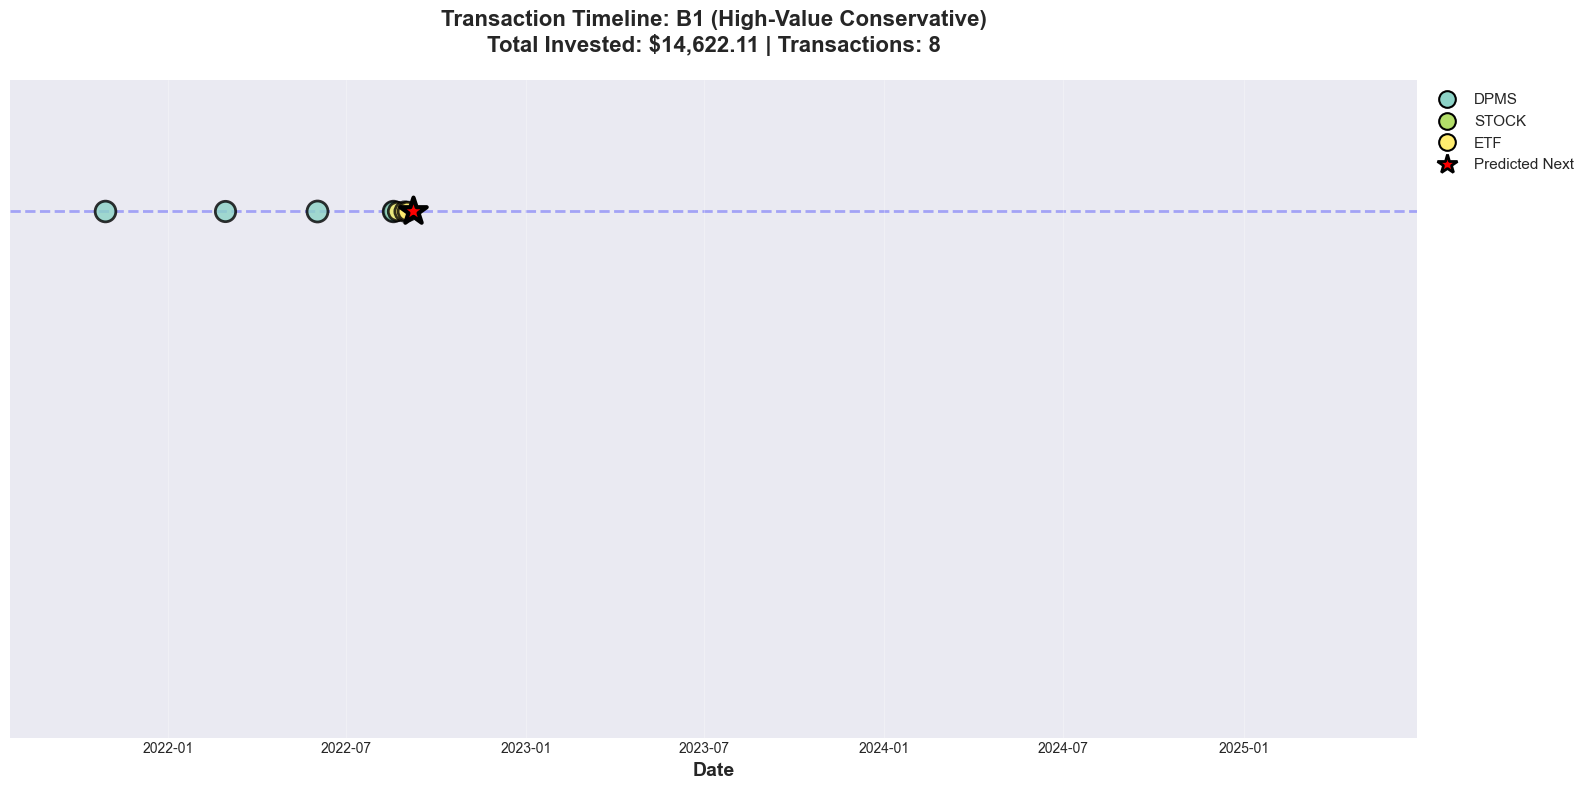


📊 Timeline Summary for B1:
   Cluster: High-Value Conservative
   First Transaction: 2021-10-29
   Last Transaction: 2022-09-01
   Product Types: DPMS, STOCK, ETF
   Most Recent: CAM HK BANKS ($234.82)

✅ Timeline visualization ready!


In [31]:
# ========================================
# CUSTOMER TIMELINE VISUALIZATION (FIXED)
# ========================================
print("📈 Creating customer timeline visualization...")

def plot_customer_timeline(focus_client, show_similar=True, n_similar=5):
    """
    Plot transaction timeline for focus customer with similar customers in background
    """
    
    # Get focus customer data
    focus_data = df[df['Client'] == focus_client].sort_values('Date')
    focus_info = client_features[client_features['Client'] == focus_client].iloc[0]
    
    if len(focus_data) == 0:
        print(f"❌ No data for client {focus_client}")
        return
    
    # Create figure with better layout
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Plot similar customers (faded background) - FIXED positioning
    similar_y_positions = []
    if show_similar:
        similar_customers = find_similar_customers(focus_client, top_n=n_similar)
        
        for idx, similar_row in similar_customers.iterrows():
            similar_client_id = similar_row['Client']
            similar_data = df[df['Client'] == similar_client_id].sort_values('Date')
            
            # Position each similar customer at different y-level
            y_pos = idx * 0.5  # Stagger them vertically
            similar_y_positions.append(y_pos)
            
            # Plot as thin gray line
            ax.scatter(similar_data['Date'], [y_pos] * len(similar_data), 
                      alpha=0.2, s=15, color='lightgray', marker='o', zorder=1)
    
    # Plot focus customer (bold) - FIXED positioning
    focus_y = (n_similar + 2) * 0.5  # Position well above similar customers
    
    # Color by product type
    product_types = focus_data['ProductType'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(product_types)))
    color_map = dict(zip(product_types, colors))
    
    # Plot each transaction
    for _, row in focus_data.iterrows():
        color = color_map[row['ProductType']]
        # Size based on amount (with better scaling)
        size = np.log1p(row['Amount']) * 15 + 100  # Logarithmic scaling
        ax.scatter(row['Date'], focus_y, s=size, alpha=0.8, 
                  color=color, edgecolors='black', linewidths=2, zorder=10)
    
    # Add predicted next purchase
    timing_info = timing_predictions[timing_predictions['Client'] == focus_client]
    if not timing_info.empty:
        pred_date = timing_info.iloc[0]['Predicted_Next_Purchase_Date']
        ax.scatter(pred_date, focus_y, s=400, marker='*', 
                  color='red', edgecolors='black', linewidths=3,
                  label='Predicted Next Purchase', zorder=15)
        
        # Add arrow
        last_date = focus_data['Date'].max()
        ax.annotate('', xy=(pred_date, focus_y), xytext=(last_date, focus_y),
                   arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle='--'))
    
    # Formatting
    ax.set_ylim(-0.5, focus_y + 1)
    ax.set_yticks([])
    ax.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax.set_title(f'Transaction Timeline: {focus_client} ({focus_info["Cluster_Name"]})\n'
                f'Total Invested: ${focus_info["Total_Invested"]:,.2f} | '
                f'Transactions: {int(focus_info["Num_Transactions"])}',
                fontsize=16, fontweight='bold', pad=20)
    
    # Add legend for product types
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=color_map[pt], markersize=12, 
                                  label=pt, markeredgecolor='black', markeredgewidth=1.5) 
                      for pt in product_types]
    
    # Add predicted purchase to legend
    if not timing_info.empty:
        legend_elements.append(plt.Line2D([0], [0], marker='*', color='w', 
                                         markerfacecolor='red', markersize=15, 
                                         label='Predicted Next', markeredgecolor='black', markeredgewidth=2))
    
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), fontsize=11)
    
    ax.grid(True, alpha=0.3, axis='x')
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add horizontal line for focus customer
    ax.axhline(y=focus_y, color='blue', linestyle='--', alpha=0.3, linewidth=2, zorder=0)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 Timeline Summary for {focus_client}:")
    print(f"   Cluster: {focus_info['Cluster_Name']}")
    print(f"   First Transaction: {focus_data['Date'].min().date()}")
    print(f"   Last Transaction: {focus_data['Date'].max().date()}")
    print(f"   Product Types: {', '.join(focus_data['ProductType'].unique())}")
    print(f"   Most Recent: {focus_data.iloc[-1]['Product']} (${focus_data.iloc[-1]['Amount']:,.2f})")

# Test visualization with a customer who has multiple transactions
test_client = client_features[client_features['Num_Transactions'] >= 5]['Client'].iloc[0]
print(f"\n🎨 Generating timeline for {test_client}...\n")
plot_customer_timeline(test_client, show_similar=True, n_similar=5)

print("\n✅ Timeline visualization ready!")

In [32]:
# Final Summary Dashboard
print("\n" + "="*70)
print("📊 ANALYSIS SUMMARY")
print("="*70)

print(f"\n✅ Dataset: {len(df)} transactions | {df['Client'].nunique()} clients")
print(f"✅ Customer Clusters: {optimal_k} segments")
for cluster_id, name in cluster_names.items():
    count = len(client_features[client_features['Cluster'] == cluster_id])
    print(f"   - {name}: {count} customers")

print(f"\n✅ Product Type Transitions: {len(transitions_df)} identified")
print(f"✅ Association Rules: {len(rules) if len(rules) > 0 else 0} rules")
print(f"\n✅ Amount Prediction Model: R² = {r2:.4f}, MAE = ${mae:,.2f}")
print(f"✅ Timing Predictions: {len(timing_predictions)} clients")
print(f"✅ Recommendations Generated: {len(recommendations_df)} clients")

print("\n" + "="*70)
print("🎯 All enhancements complete! Ready for analysis.")
print("="*70)


📊 ANALYSIS SUMMARY

✅ Dataset: 3171 transactions | 190 clients
✅ Customer Clusters: 4 segments
   - High-Value Conservative: 48 customers
   - High-Value Conservative: 118 customers
   - High-Value Active Trader: 23 customers
   - Ultra High-Net-Worth: 1 customers

✅ Product Type Transitions: 2281 identified
✅ Association Rules: 115 rules

✅ Amount Prediction Model: R² = 0.4114, MAE = $11,754.40
✅ Timing Predictions: 190 clients
✅ Recommendations Generated: 190 clients

🎯 All enhancements complete! Ready for analysis.
